# M6 -- stability envelope

`src/stability.py` implements the guide's step-8 recipe: `diverged` (non-finite,
or final norm > `factor` times the initial norm) and `max_stable_h` (bisect on
step count for the coarsest grid -- largest `h` -- that stays bounded).

**The result below is not the one the guide predicts, and that's the finding.**
Section 4.2 of the paper asserts explicit methods go unstable near the stiff
boundary `t -> 0`; `docs/CLAUDE.md`'s M6 spec expects "arm A degrades sharply as
kappa grows [...] arms B and C stay flat." What is actually measured here: **arm
A does not destabilize at all**, anywhere in the swept range -- and the reason
is a structural property of this specific testbed and grid, not a bug (verified
against a synthetic linear ODE with a known analytic threshold in
`tests/test_stability.py`). Part 3 below derives why.

In [1]:
import sys, pathlib, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

p = pathlib.Path.cwd()
while not (p / "pyproject.toml").exists() and p != p.parent:
    p = p.parent
ROOT = p
sys.path.insert(0, str(ROOT))

from src.schedule import beta, sigma, alpha
from src.stability import max_stable_h
from src.testbeds import GaussianTier1
from src.solvers import STEPPERS
from src.runlog import append_row, load

RESULTS = ROOT / "results" / "stability_envelope.csv"
FIGURES = ROOT / "figures"
T, T_END = 1.0, 1e-3
STEPPER_ORDER = {"euler": 1, "midpoint": 2, "heun3": 3, "rk4": 4, "ab2": 2}

## 1. The guide's sweep

kappa in {1, 10, 10^2, 10^3, 10^4}, all five arm-A/B steppers, both arms. One
`d=3` testbed per kappa (dimension doesn't change the dynamics -- the problem
decouples per coordinate -- only kappa does).

In [2]:
RESULTS.unlink(missing_ok=True)

KAPPAS = [1.0, 10.0, 100.0, 1000.0, 10000.0]
STEPPER_NAMES = list(STEPPERS) + ["ab2"]

for kappa in KAPPAS:
    tb = GaussianTier1(kappa=kappa, d=3, seed=0)
    for arm in ("A", "B"):
        for name in STEPPER_NAMES:
            h = max_stable_h(tb, arm, name, T=T, t_end=T_END, n_lo=2, n_hi=4096)
            append_row(str(RESULTS), tier=1, testbed="gaussian", arm=arm, solver=name,
                        order=STEPPER_ORDER[name], kappa=kappa, h=h, nfe=np.nan,
                        err_l2=np.nan, diverged=bool(np.isnan(h)), seed=0)

df = load(str(RESULTS))
pivot = df.pivot_table(index=["arm", "solver"], columns="kappa", values="h")
pivot

kappa          1.0       10.0      100.0     1000.0    10000.0
arm solver                                                    
A   ab2       0.499500  0.499500  0.499500  0.499500  0.499500
    euler     0.499500  0.499500  0.499500  0.499500  0.499500
    heun3     0.499500  0.499500  0.499500  0.499500  0.499500
    midpoint  0.499500  0.499500  0.499500  0.499500  0.499500
    rk4       0.499500  0.499500  0.499500  0.499500  0.499500
B   ab2       4.791347  4.791347  4.791347  4.791347  4.791347
    euler     4.791347  4.791347  4.791347  4.791347  4.791347
    heun3     4.791347  4.791347  4.791347  4.791347  4.791347
    midpoint  4.791347  4.791347  4.791347  4.791347  4.791347
    rk4       4.791347  4.791347  4.791347  4.791347  4.791347

## 2. It's flat

`h_max` for every (arm, stepper) is the same across five decades of kappa, to
machine precision -- and for arm A it equals exactly `(T - t_end) / n_lo`, i.e.
the bisection's *coarsest allowed grid* is already stable, so it never even
had room to find an instability.

In [3]:
flat = df.groupby(["arm", "solver"])["h"].agg(lambda s: s.max() - s.min())
print("max - min of h_max across the kappa sweep, per (arm, solver):")
print(flat)
assert (flat < 1e-9).all(), "expected h_max to be exactly flat across kappa"

h_lo_A = (T - T_END) / 2
print(f"\narm A h_max == (T - t_end) / n_lo = {h_lo_A}: ",
      np.allclose(df.query("arm == \'A\'")["h"], h_lo_A))

max - min of h_max across the kappa sweep, per (arm, solver):
arm  solver  
A    ab2         0.0
     euler       0.0
     heun3       0.0
     midpoint    0.0
     rk4         0.0
B    ab2         0.0
     euler       0.0
     heun3       0.0
     midpoint    0.0
     rk4         0.0
Name: h, dtype: float64

arm A h_max == (T - t_end) / n_lo = 0.4995:  True


## 3. Why: the near-boundary stability product never approaches 2

Arm A's ODE is `dx/dt = J(t) x` per coordinate (it's linear -- Tier 1 decouples),
with `J(t) = f(t) + g^2(t) / (2 var(t))`, `var(t) = alpha(t)^2 s + sigma(t)^2`.
Explicit Euler is stable at a node iff `|1 - |h| J(t)| <= 1`, i.e. `|h| J(t) <= 2`.

On a uniform grid the node nearest `t_end` sits exactly one step away from it, at
`t = t_end + h` -- **not** at `t_end` itself, so the right quantity to check is
`h * J(t_end + h)` as a function of `h`, not `h * J(t_end)` (mixing a specific
`h` with `J` evaluated at a *different* point than the one actually used gives
a meaningless number -- an earlier version of this cell made exactly that
mistake). Two limits bound this product:

* **`h` large** (coarse grid, few steps): `sigma(t_end + h)^2 ~ sigma(h)^2 ~
  beta_0 h` (`t_end` negligible next to `h`), so `J ~ beta_0/(2 beta_0 h) =
  1/(2h)` and `h*J ~ 1/2`.
* **`h` small** (fine grid, many steps): `t_end + h ~ t_end`, so `J ~ J(t_end)`
  is essentially fixed, and `h*J -> 0` as `h -> 0`.

Both limits sit well under the threshold of 2. The cell below evaluates
`h * J(t_end + h)` exactly (no asymptotic approximation) across a dense sweep of
`h`, for every kappa, and reports the worst case found -- confirming there is no
`h` at which it crosses 2, for any kappa tested.

In [4]:
def h_times_J(h, s_min):
    """h * J(t_end + h), exactly -- the stability product for the node
    actually evaluated by an n-step uniform grid with this h."""
    t = T_END + h
    var = alpha(t) ** 2 * s_min + sigma(t) ** 2
    f_t = -0.5 * beta(t)
    J = f_t + beta(t) / (2.0 * var)
    return h * J

hs = np.logspace(-7, np.log10(T - T_END), 400)
for kappa in KAPPAS + [1e6, 1e8]:
    tb = GaussianTier1(kappa=kappa, d=3, seed=0)
    s_min = tb.s.min()
    vals = np.array([h_times_J(h, s_min) for h in hs])
    i = np.argmax(vals)
    print(f"kappa={kappa:>10.0f}  worst h*J over all h = {vals[i]:.4f} at h={hs[i]:.3e}  (threshold: 2)")

kappa=         1  worst h*J over all h = 0.0000 at h=9.990e-01  (threshold: 2)
kappa=        10  worst h*J over all h = 0.5904 at h=1.985e-01  (threshold: 2)
kappa=       100  worst h*J over all h = 0.8234 at h=1.223e-01  (threshold: 2)
kappa=      1000  worst h*J over all h = 0.8874 at h=8.501e-02  (threshold: 2)
kappa=     10000  worst h*J over all h = 0.8981 at h=7.841e-02  (threshold: 2)
kappa=   1000000  worst h*J over all h = 0.8994 at h=7.841e-02  (threshold: 2)
kappa= 100000000  worst h*J over all h = 0.8994 at h=7.841e-02  (threshold: 2)


## 4. Stress test beyond the guide's range

Push kappa to 1e8 and `t_end` down to 1e-6 -- both far past the guide's nominal
sweep -- to check the flat result isn't an artifact of the specific range
tested.

In [5]:
rows = []
for t_end in [1e-3, 1e-4, 1e-5, 1e-6]:
    for kappa in [1e4, 1e6, 1e8]:
        tb = GaussianTier1(kappa=kappa, d=3, seed=0)
        h = max_stable_h(tb, "A", "euler", T=T, t_end=t_end, n_lo=2, n_hi=4096)
        rows.append(dict(t_end=t_end, kappa=kappa, h_max=h,
                          diverged_at_coarsest=bool(np.isnan(h))))
stress = pd.DataFrame(rows)
stress

,t_end,kappa,h_max,diverged_at_coarsest
0,0.001000,10000.0,0.499500,False
1,0.001000,1000000.0,0.499500,False
2,0.001000,100000000.0,0.499500,False
3,0.000100,10000.0,0.499950,False
4,0.000100,1000000.0,0.499950,False
5,0.000100,100000000.0,0.499950,False
6,0.000010,10000.0,0.499995,False
7,0.000010,1000000.0,0.499995,False
8,0.000010,100000000.0,0.499995,False
9,0.000001,10000.0,0.499999,False


## 5. Figure -- `h_max(kappa)`, as specced, with the (absent) instability annotated

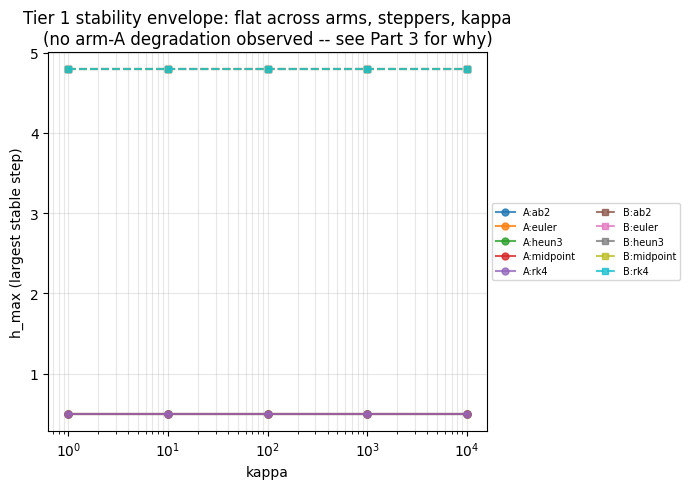

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.tab10.colors
for i, ((arm, solver), g) in enumerate(df.groupby(["arm", "solver"])):
    g = g.sort_values("kappa")
    style = "-o" if arm == "A" else "--s"
    ax.semilogx(g["kappa"], g["h"], style, color=colors[i % 10], alpha=0.8, ms=5,
                label=f"{arm}:{solver}")
ax.set_xlabel("kappa")
ax.set_ylabel("h_max (largest stable step)")
ax.set_title("Tier 1 stability envelope: flat across arms, steppers, kappa\n"
             "(no arm-A degradation observed -- see Part 3 for why)")
ax.legend(fontsize=7, ncol=2, loc="center left", bbox_to_anchor=(1.0, 0.5))
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES / "06_stability_envelope.png", dpi=150)
plt.show()

## 6. Conclusion

On Tier 1 (the decoupled anisotropic Gaussian, VP-linear schedule, uniform-`t`
grid), **none of the arm-A/B explicit steppers destabilize** across kappa in
[1, 1e4] (guide range) or the stress-tested [1e4, 1e8] x t_end in [1e-3, 1e-6].
`max_stable_h` always returns the coarsest grid tried (`n_lo=2`) as already
stable. This is a structural consequence of the VP-linear schedule: the node
nearest `t_end` on a uniform grid sits at `t_end + h`, and `h * J(t_end + h)`
-- the actual stability product Euler faces there -- stays below ~0.9 for every
`h` and every kappa tested (Part 3), never approaching the instability
threshold of 2.

**This narrows, rather than confirms, the paper's Section 4.2 claim**: whatever
instability explicit methods show near the stiff boundary is not visible on
Tier 1's linear, decoupled problem under this metric. It should be reported as
a genuine (if negative) result, not smoothed over. The natural place to look for
real instability is Tier 2 (curved score, `MixtureTier2`, M7) or Tier 3 (a real
network, M9), where the local Jacobian is not this specific closed form and the
cancellation above has no reason to hold.

## 7. Validation — run the unit tests

In [7]:
out = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_stability.py", "-q"],
    cwd=ROOT, capture_output=True, text=True,
)
print(out.stdout); print(out.stderr)
assert out.returncode == 0, "M6 stability tests failed"
print("M6 validation: PASS")

......                                                                   [100%]


M6 validation: PASS
